# 零售会员产品 · 开发版 notebook（development）

> 这份 notebook 是**开发阶段**的样子：所有逻辑都直接写在 cell 里，方便边写边调、边看中间结果。
> 等流程跑通、确认无误后，才会把这些代码整理成函数、打包进 `pipeline.py`。
>
> **和 `showcase.ipynb` 的区别**
> - `showcase.ipynb`：**给别人看成果**用的，直接 `import pipeline` 调函数，干净；
> - 这份 `development.ipynb`：**给自己跑**用的，代码全部内联（inline），默认用 **30% 客户**快速迭代（50% 也能跑但更慢，全量会 OOM 8GB 笔记本）。

**数据集**：X5 RetailHero（一次真实的零售会员随机实验）。三张原始表用 `client_id` 关联：

| 表 | 是什么 |
|---|---|
| `train` | 实验客户，含 `treatment_flg`（是否收到推送）+ `target`（实验观测窗口内是否发生购买） |
| `clients` | 客户信息（年龄、性别、注册时间） |
| `purchases` | 原始购物流水，**全部发生在推送之前** |

整体一条主线：**先看懂产品**（指标 / 留存 / 分群）→ **再对产品做实验**（效果 / uplift / 投放 / 监控）。

In [85]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats

# 三个关键列（定义清楚，后面到处都用）
TREATMENT = "treatment_flg"   # 1 = 收到推送, 0 = 对照组
OUTCOME   = "target"          # 购买指标：1 = 实验窗口内有购买, 0 = 没买
ID        = "client_id"       # 三张表的关联主键

SEED = 42
SAMPLE_FRAC = 0.3   # 30% 客户：快速迭代（fetch_x5 整表读入 45.8M 行，全量在 DuckDB 聚合会 OOM 8GB 笔记本；50% 也能跑但更慢）

# 数据缓存在本目录的 data/ 下（和 pipeline.py 保持一致，项目自包含）
DATA_DIR = os.path.join(os.getcwd(), "data")

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)
print("DATA_DIR =", DATA_DIR, " | SAMPLE_FRAC =", SAMPLE_FRAC)

DATA_DIR = /Users/guangyuwang/projects/job2026/resume/portfolio/project1-uplift/data  | SAMPLE_FRAC = 0.3


## 一个 SQL 小工具

重活（按客户聚合、cohort 留存、RFM）我想用 **SQL** 来写——既练 SQL，又贴近真实数仓里的工作方式。
DuckDB 可以直接在内存里的 pandas 表上跑 SQL，所以先写个小函数：每个关键字参数名就是一张可查询的 SQL 表。

In [62]:
import duckdb

def duck(sql, **frames):
    """在内存里的 pandas 表上跑 SQL（DuckDB）。每个关键字参数名 = 一张 SQL 表。"""
    con = duckdb.connect()
    try:
        # 单线程：并行浮点求和顺序不定会让聚合特征有 ~1e-10 抖动，配合后面按
        # client_id 排序，能让整条 uplift 链路可复现（uplift 信号很弱，对特征抖动敏感）
        con.execute("SET threads TO 1")
        for name, frame in frames.items():
            con.register(name, frame)
        return con.execute(sql).df()
    finally:
        con.close()

# 快速自测一下
duck("SELECT 1 AS ok")

,ok
0,1


## 看懂产品

### Step 1 · 加载三张原始表

X5 给的是**原始日志**，不是整理好的特征表。`fetch_x5` 会自动下载 + 缓存（首次约 640MB），
返回 `train` / `clients` / `purchases` 三张表，target/treatment 单独作为 Series 返回。

开发阶段：在**客户层面**抽样 30%，再只保留这些客户的流水——在客户层面抽样能保证每个人的聚合特征内部一致。

In [63]:
from sklift.datasets import fetch_x5

bunch = fetch_x5(data_home=DATA_DIR)
clients = bunch.data["clients"].copy()
train   = bunch.data["train"].copy()

# fetch_x5 把 target / treatment 作为单独的 Series 返回，对齐到 train，先贴回去
train[OUTCOME]   = bunch.target.values
train[TREATMENT] = bunch.treatment.values

# 开发阶段抽样：先在客户层面抽 30%，再只保留这些客户的流水
if SAMPLE_FRAC is not None and SAMPLE_FRAC < 1.0:
    train = train.sample(frac=SAMPLE_FRAC, random_state=SEED).reset_index(drop=True)
    keep = set(train[ID])
    purchases = bunch.data["purchases"]
    purchases = purchases[purchases[ID].isin(keep)].reset_index(drop=True)
else:
    purchases = bunch.data["purchases"]

print(f"train={len(train):,}  clients={len(clients):,}  purchases={len(purchases):,}")
train.head(3)

train=60,012  clients=400,162  purchases=6,843,173


,client_id,target,treatment_flg
0,ac126a8be6,0,0
1,ba4a67aba7,1,0
2,b2fc4ea450,0,0


In [68]:
# 开发时随手看看另外两张表长什么样
print("clients:")
display(clients.head(3))
print("purchases（原始流水，每行是一笔交易里的一个商品）:")
display(purchases.head(3))

clients:


,client_id,first_issue_date,first_redeem_date,age,gender
0,000012768d,2017-08-05 15:40:48,2018-01-04 19:30:07,45,U
1,000036f903,2017-04-10 13:54:23,2017-04-23 12:37:56,72,F
2,000048b7a6,2018-12-15 13:33:11,NaN,68,F


purchases（原始流水，每行是一笔交易里的一个商品）:


,client_id,transaction_id,transaction_datetime,regular_points_received,express_points_received,regular_points_spent,express_points_spent,purchase_sum,store_id,product_id,product_quantity,trn_sum_from_iss,trn_sum_from_red
0,000012768d,7e3e2e3984,2018-12-01 07:12:45,10.0,0.0,0.0,0.0,1007.0,54a4a11a29,9a80204f78,2.0,80.0,NaN
1,000012768d,7e3e2e3984,2018-12-01 07:12:45,10.0,0.0,0.0,0.0,1007.0,54a4a11a29,da89ebd374,1.0,65.0,NaN
2,000012768d,7e3e2e3984,2018-12-01 07:12:45,10.0,0.0,0.0,0.0,1007.0,54a4a11a29,0a95e1151d,1.0,24.0,NaN


### Step 2 · SQL 聚合层：把流水压成「每个客户一行」的特征

这是最重的一步，用 **SQL（DuckDB）** 做。CTE 一层层往上卷：商品行 → 交易 → 客户，
产出 RFM 风格 + 行为特征（消费、客单、商品/门店广度、积分、recency、tenure）。

**防泄漏**：这里每一笔购买都发生在推送之前，所以每个聚合都是合法的「实验前」协变量，没有用到任何推送之后的信号。

In [69]:
# 时间列转成 datetime，并用最后一笔交易时间当作「营销开始」的代理时间点
purchases["transaction_datetime"] = pd.to_datetime(
    purchases["transaction_datetime"], errors="coerce")
ref = purchases["transaction_datetime"].max()
print("参考时间点（最后一笔交易）:", ref)

feats = duck(
    """
    WITH tx AS (                       -- 商品行 -> 每笔交易一行
        SELECT client_id, transaction_id,
               MAX(purchase_sum)            AS tx_sum,
               COUNT(DISTINCT product_id)   AS tx_items,
               MAX(transaction_datetime)    AS tx_time,
               MAX(regular_points_received) AS tx_pts_received,
               MAX(regular_points_spent)    AS tx_pts_spent,
               MAX(express_points_received) AS tx_exp_received,
               MAX(express_points_spent)    AS tx_exp_spent,
               MAX(trn_sum_from_iss)        AS tx_sum_from_iss,
               MAX(trn_sum_from_red)        AS tx_sum_from_red
        FROM purchases
        GROUP BY client_id, transaction_id
    ),
    cust AS (                          -- 交易 -> 每个客户一行
        SELECT client_id,
               COUNT(*)            AS n_tx,
               SUM(tx_sum)         AS spend_total,
               AVG(tx_sum)         AS spend_mean,
               STDDEV_SAMP(tx_sum) AS spend_std,
               AVG(tx_items)       AS basket_mean,
               MAX(tx_time)        AS last_tx,
               MIN(tx_time)        AS first_tx,
               SUM(tx_pts_received) AS pts_received,
               SUM(tx_pts_spent)    AS pts_spent,
               SUM(tx_exp_received) AS exp_pts_received,
               SUM(tx_exp_spent)    AS exp_pts_spent,
               AVG(tx_sum_from_iss) AS sum_from_iss_mean,
               AVG(tx_sum_from_red) AS sum_from_red_mean
        FROM tx GROUP BY client_id
    ),
    prod AS (                          -- 广度：买过多少种商品 / 逛过多少店
        SELECT client_id,
               COUNT(DISTINCT product_id)   AS n_products,
               COUNT(DISTINCT store_id)     AS n_stores
        FROM purchases GROUP BY client_id
    )
    SELECT c.*, p.n_products, p.n_stores
    FROM cust c LEFT JOIN prod p USING (client_id)
    """,
    purchases=purchases,
)
print("聚合后:", feats.shape)
feats.head(3)

参考时间点（最后一笔交易）: 2019-03-18 23:19:28
聚合后: (60012, 16)


,client_id,n_tx,spend_total,spend_mean,spend_std,basket_mean,last_tx,first_tx,pts_received,pts_spent,exp_pts_received,exp_pts_spent,sum_from_iss_mean,sum_from_red_mean,n_products,n_stores
0,000012768d,4,2803.00,700.750000,258.000484,13.000000,2019-03-14 15:01:47,2018-12-01 07:12:45,25.7,0.0,0.0,0.0,136.000000,NaN,46,3
1,00020e7b18,18,25819.61,1434.422778,1008.952394,15.111111,2019-03-15 12:04:23,2018-11-23 08:21:26,286.1,-592.0,0.0,-30.0,243.333333,306.4,175,4
2,00022fd34f,33,6852.51,207.651818,181.406950,3.515152,2019-03-16 07:59:56,2018-11-23 14:30:05,67.0,-48.0,0.0,0.0,107.969697,65.0,69,2


In [70]:
# recency / tenure 用 Python 算更直观
feats["last_tx"]  = pd.to_datetime(feats["last_tx"])
feats["first_tx"] = pd.to_datetime(feats["first_tx"])
feats["recency_days"] = (ref - feats["last_tx"]).dt.days
feats["tenure_days"]  = (feats["last_tx"] - feats["first_tx"]).dt.days
feats = feats.drop(columns=["last_tx", "first_tx"])

# 拼上人口属性 + 办卡/兑换日期信号。first_redeem_date 系列（是否兑过分、多快兑、
# 多久没兑）是 uplift 质量最大的杠杆——兑换揭示了对促销敏感的人，正是活动能撬动的对象。
demo_cols = [c for c in ("age", "gender") if c in clients.columns]
date_cols = [c for c in ("first_issue_date", "first_redeem_date") if c in clients.columns]
cl = clients[[ID] + demo_cols + date_cols].copy()
for c in date_cols:
    cl[c] = pd.to_datetime(cl[c], errors="coerce")
if "first_issue_date" in cl.columns:
    cl["issue_tenure_days"] = (ref - cl["first_issue_date"]).dt.days
if "first_redeem_date" in cl.columns:
    cl["has_redeemed"]        = cl["first_redeem_date"].notna().astype(float)
    cl["redeem_recency_days"] = (ref - cl["first_redeem_date"]).dt.days
    if "first_issue_date" in cl.columns:
        cl["issue_to_redeem_days"] = (cl["first_redeem_date"] - cl["first_issue_date"]).dt.days
cl = cl.drop(columns=date_cols)

df = (train.merge(feats, on=ID, how="left")
           .merge(cl, on=ID, how="left"))
if "gender" in df.columns:
    df = pd.get_dummies(df, columns=["gender"], dummy_na=True, drop_first=True)

# 固定行顺序：上面 DuckDB 聚合是并行的，输出顺序不稳定；按 client_id 排序，
# 保证后面的 train/test 划分（以及所有 uplift 指标）可复现
df = df.sort_values(ID, kind="mergesort").reset_index(drop=True)

feature_names = [c for c in df.columns if c not in (ID, OUTCOME, TREATMENT)]
print(f"customers={len(df):,}  n_features={len(feature_names)}")
print("特征列:", feature_names)
df.head(3)

customers=60,012  n_features=23
特征列: ['n_tx', 'spend_total', 'spend_mean', 'spend_std', 'basket_mean', 'pts_received', 'pts_spent', 'exp_pts_received', 'exp_pts_spent', 'sum_from_iss_mean', 'sum_from_red_mean', 'n_products', 'n_stores', 'recency_days', 'tenure_days', 'age', 'issue_tenure_days', 'has_redeemed', 'redeem_recency_days', 'issue_to_redeem_days', 'gender_M', 'gender_U', 'gender_nan']


,client_id,target,treatment_flg,n_tx,spend_total,spend_mean,spend_std,basket_mean,pts_received,pts_spent,exp_pts_received,exp_pts_spent,sum_from_iss_mean,sum_from_red_mean,n_products,n_stores,recency_days,tenure_days,age,issue_tenure_days,has_redeemed,redeem_recency_days,issue_to_redeem_days,gender_M,gender_U,gender_nan
0,000012768d,1,0,4,2803.00,700.750000,258.000484,13.000000,25.7,0.0,0.0,0.0,136.000000,NaN,46,3,4,103,45,590,1.0,438.0,152.0,False,True,False
1,00020e7b18,1,1,18,25819.61,1434.422778,1008.952394,15.111111,286.1,-592.0,0.0,-30.0,243.333333,306.4,175,4,3,112,73,476,1.0,432.0,44.0,False,True,False
2,00022fd34f,1,1,33,6852.51,207.651818,181.406950,3.515152,67.0,-48.0,0.0,0.0,107.969697,65.0,69,2,2,112,65,458,1.0,314.0,144.0,False,True,False


### Step 3 · 产品分析：核心指标 + cohort 留存 + RFM 分群

动手做实验之前，先看清产品现状。三个经典视角：
1. **核心指标** — 频次、金额、recency（全部推送前历史口径；购买率改用对照组测量，移到实验部分 Step 5）
2. **获客 cohort 留存** — 按首购月份分组，看 m 个月后还有多少人活跃
3. **RFM 分群** — SQL `NTILE` 切五档 → champions / at_risk / mid（后面做投放护栏会用到）

In [71]:
# 1) 核心产品指标：扫一眼产品健康度（全部推送前历史口径，保持纯实验前视角）
#    购买率改用对照组测量，移到实验部分，见 Step 5。
metrics = {
    "customers": int(len(df)),
    "avg_purchase_frequency": round(float(df["n_tx"].mean()), 2),
    "avg_monetary_per_customer": round(float(df["spend_total"].mean()), 2),
    "median_recency_days": float(df["recency_days"].median()),
}
metrics

{'customers': 60012,
 'avg_purchase_frequency': 20.1,
 'avg_monetary_per_customer': 8551.32,
 'median_recency_days': 4.0}

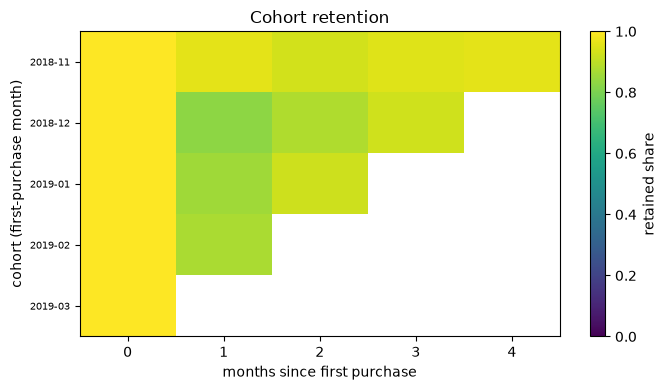

month_offset,0,1,2,3,4
cohort,,,,,
2018-11-01,1.0,0.96,0.93,0.95,0.96
2018-12-01,1.0,0.83,0.88,0.93,NaN
2019-01-01,1.0,0.86,0.92,NaN,NaN
2019-02-01,1.0,0.87,NaN,NaN,NaN
2019-03-01,1.0,NaN,NaN,NaN,NaN


In [72]:
# 2) 获客 cohort 留存（SQL）：按首购月份分组，看 m 个月后还有多少人活跃
cohort = duck(
    """
    WITH first_m AS (
        SELECT client_id, date_trunc('month', MIN(transaction_datetime)) AS cohort
        FROM purchases GROUP BY client_id
    ),
    act AS (
        SELECT DISTINCT client_id, date_trunc('month', transaction_datetime) AS active_month
        FROM purchases
    )
    SELECT f.cohort,
           date_diff('month', f.cohort, a.active_month) AS month_offset,
           COUNT(*) AS n_active
    FROM first_m f JOIN act a USING (client_id)
    GROUP BY 1, 2 ORDER BY 1, 2
    """,
    purchases=purchases,
)
pivot = cohort.pivot(index="cohort", columns="month_offset", values="n_active")
retention = pivot.div(pivot[0], axis=0)   # month_offset 0 = cohort 基数

fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(retention.values, aspect="auto", cmap="viridis", vmin=0, vmax=1)
ax.set_title("Cohort retention")
ax.set_xlabel("months since first purchase"); ax.set_ylabel("cohort (first-purchase month)")
ax.set_yticks(range(len(retention)))
ax.set_yticklabels([str(c)[:7] for c in retention.index], fontsize=7)
fig.colorbar(im, ax=ax, label="retained share")
plt.tight_layout(); plt.show()
retention.round(2)

In [73]:
# 3) RFM 分群（SQL NTILE）：R/F/M 各切 5 档，R 越大=越近期，再贴标签
rfm_in = df.dropna(subset=["recency_days", "n_tx", "spend_total"])[
    [ID, "recency_days", "n_tx", "spend_total"]]
rfm = duck(
    """
    SELECT client_id,
           NTILE(5) OVER (ORDER BY recency_days DESC, client_id) AS R,
           NTILE(5) OVER (ORDER BY n_tx, client_id)              AS F,
           NTILE(5) OVER (ORDER BY spend_total, client_id)       AS M
    FROM rfm_in
    """,
    rfm_in=rfm_in,
)
rfm["rfm_segment"] = np.where((rfm.R >= 4) & (rfm.F >= 4), "champions",
                     np.where((rfm.R <= 2) & (rfm.F <= 2), "at_risk", "mid"))

df = df.merge(rfm[[ID, "rfm_segment"]], on=ID, how="left")
df["rfm_segment"] = df["rfm_segment"].fillna("unknown")
print(df["rfm_segment"].value_counts().to_dict())

{'mid': 29983, 'at_risk': 15027, 'champions': 15002}


## 对产品做实验

### Step 4 · 实验设计 & 体检

先把标准 A/B test 的**设计骨架**写明（即便 X5 实验已经跑完，这部分是上线前 PM/DS 要定的）：
- **假设** — H0：实验组/对照组购买率相等；Ha：不相等（双尾）。
- **指标分层**（实验前钉死，杜绝事后挑指标 / p-hacking）：
  - **Primary（唯一 gate launch 的检验指标）** — 购买率 `target`（实验窗口内是否购买）；power / 样本量按它算。
  - **Secondary（描述性，不单独决定 launch）** — 效果在关键人群上的方向与分布：按 RFM 分群看 treated/control 购买率，确认 lift 不是只由单一人群撑起（Step 5 评）。⚠️ 真实活动的 secondary 还应含客单价 / 频次 / 留存，但 X5 公开样本的实验窗口只暴露二值 `target`，连续型 secondary 无法从本数据算，仅列入生产监控清单。
  - **Guardrail（一票否决：任一不过，即使 primary 赢也 HOLD）** — 均为**人群层 do-no-harm**，在 **Step 5** 评估：G1 没有任何 RFM 分群被显著做差；G2 lift 不是主要来自本就会买的 champions（否则是在薅忠诚会员 / 给反正会买的人发券）。
- ⚠️ 这里的 guardrail 是**全员发**场景的实验护栏（「活动对谁有没有害」），与 **Step 8** 的**只发 top-k%** 投放护栏（「模型挑人挑得对不对」）是两码事，不能相互替代。
- **功效 / 样本量** — 基线率必须用**实验前**就能拿到的数据估（不能用实验自己的 outcome，否则因果颠倒）。这里用推送前历史的「最近 7 天购买率」作基线（`recency_days ≤ 7`，纯推送前特征），配目标 MDE（+1pp），算标准两比例检验在 `alpha=0.05, power=0.80` 下每组需要多少人，再对照 X5 实际样本量看够不够 power。（这个历史 7 天率 ≈ 后面对照组的购买率，互为印证。）

再过**事后体检**三关（拿到真实数据、信任任何效果估计之前）：
- **SRM（样本比例失衡）** — 实验组/对照组实际人数 vs 设计比例 的卡方检验，抓管道/埋点 bug。
- **协变量平衡（SMD）** — 每个特征的标准化均值差，干净的随机实验里大多数应 `|SMD| < 0.1`。（有实验前期数据时，AA test 是另一种经典随机化检验。）
- **base rate（按组拆开）** — control 是对照组购买率（基线），treat 是实验组购买率，`diff` 即朴素 ATE 的预览。混在一起的全样本均值会把基线/效果/分流比例搅在一起，没有干净含义，所以分组报。

In [74]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

n = len(df)
n_t = int(df[TREATMENT].sum())
n_c = n - n_t

# --- 实验设计：假设 + 功效/样本量 ---
# H0: rate_treat == rate_control；Ha: 不相等（双尾）。主指标 = 购买率 target。
# 样本量必须用【实验前就能拿到的数据】定，绝不能用实验自己的 outcome（否则因果颠倒：
# 还没跑完怎么会知道结果）。这里用推送前历史估基线购买率：最近 window 天内买过的客户占比
# —— recency_days 是推送前特征，window 取与 target 测量窗口一致。
window = 7   # 天；与 target 的定义窗口一致（历史 7 天购买率 ≈ 后面对照组购买率，互为印证）
base_rate = float((df["recency_days"] <= window).mean())
mde = 0.01   # 关心的最小可检测效应：+1 个百分点
h = proportion_effectsize(base_rate + mde, base_rate)    # Cohen's h
req_n = NormalIndPower().solve_power(effect_size=h, alpha=0.05, power=0.80,
                                     alternative="two-sided")
print(f"[设计] H0: treat==control（双尾, alpha=0.05, power=0.80）")
print(f"[设计] 基线(历史{window}天)={base_rate:.4f}  MDE=+{mde:.3f}  "
      f"每组需 ~{int(np.ceil(req_n)):,} 人  实际每组 ~{min(n_t, n_c):,} 人 "
      f"-> {'够 power' if min(n_t, n_c) >= req_n else '欠 power'}")

# --- 体检：分流 + SRM + 平衡 + base rate ---
print(f"treat={n_t:,} ({n_t/n:.3f})  control={n_c:,} ({n_c/n:.3f})")

# SRM：按 50/50 设计比例做卡方（X5 没公布设计比例，先按最可能的 50/50 测）
chi2, p = stats.chisquare([n_t, n_c], f_exp=[n/2, n/2])
print(f"[SRM] chi2={chi2:.2f}  p={p:.3f}  ({'OK' if p > 0.001 else 'MISMATCH - 要查'})")

# 协变量平衡 SMD
num_feats = [f for f in feature_names if pd.api.types.is_numeric_dtype(df[f])]
t = df[df[TREATMENT] == 1]
c = df[df[TREATMENT] == 0]
smd = {}
for f in num_feats:
    pooled_sd = np.sqrt((t[f].var() + c[f].var()) / 2)
    if pooled_sd and pooled_sd > 0:
        smd[f] = (t[f].mean() - c[f].mean()) / pooled_sd
worst = sorted(smd.items(), key=lambda kv: -abs(kv[1]))[:5]
print("最大的 |SMD|:", [(f, round(v, 3)) for f, v in worst])

# base rate 按组拆开看：control 是对照组购买率（基线），treat 是实验组购买率，
# diff 就是朴素 ATE 的预览。混在一起的全样本均值会把基线/效果/分流比例搅在一起，
# 没有干净的业务含义，所以分组报。
rate_t = df.loc[df[TREATMENT] == 1, OUTCOME].mean()
rate_c = df.loc[df[TREATMENT] == 0, OUTCOME].mean()
print(f"{OUTCOME} rate: control={rate_c:.4f}  treat={rate_t:.4f}  diff={rate_t - rate_c:.4f}")

[设计] H0: treat==control（双尾, alpha=0.05, power=0.80）
[设计] 基线(历史7天)=0.6761  MDE=+0.010  每组需 ~34,096 人  实际每组 ~29,876 人 -> 欠 power
treat=30,136 (0.502)  control=29,876 (0.498)
[SRM] chi2=1.13  p=0.289  (OK)
最大的 |SMD|: [('has_redeemed', np.float64(0.023)), ('exp_pts_received', np.float64(0.022)), ('n_tx', np.float64(0.012)), ('spend_std', np.float64(0.01)), ('redeem_recency_days', np.float64(-0.009))]
target rate: control=0.6007  treat=0.6367  diff=0.0360


### Step 5 · 平均处理效果（ATE）+ 显著性检验 + 上线决策

0. **对照组购买率（基线）** — 先报对照组购买率作为基线（只有没收到推送的对照组，量到的才是不投放时的水平）；
1. **朴素差 + 95% CI** — 两组购买率之差；
2. **两比例 z 检验** — 标准 A/B test 的显著性判定（H0：两组率相等），给出 p 值。注意它在 H0 下用 **pooled 方差**，与第 1 步 CI 的 **unpooled 方差**不同口径，二者只是大样本下渐近一致、并非严格等价；
3. **CUPED（单协变量，纵向）** — 用实验前同口径信号（最近 7 天是否购买）做方差缩减：`Y_cuped = Y − θ(X − E[X])`，`θ = Cov(Y,X)/Var(X)`。随机分组下点估计不变、SE 变小，并给出 z/p；
4. **回归调整（ANCOVA，多协变量）** — 把一堆实验前协变量一起放进 OLS，treatment 系数即调整后 ATE。**CUPED 是它的单协变量特例**，多协变量通常降方差更多（用更少样本拿到同样精度）。CUPED 与 ANCOVA 的 CI 和 p 都基于同一个 SE，所以二者**严格等价**；
5. **Secondary + Guardrail（人群层，见下方续格）** — 按 RFM 分群拆 ATE：**secondary** 看 lift 的人群分布（描述性、不 gate）；**guardrail** 一票否决——G1 没有分群被显著做差、G2 champions 不是 lift 的主要来源；
6. **上线决策** — 事前指定 **ANCOVA 为 primary**（SE 最小、把方差缩减真正用在决策上），naive/CUPED 仅作 sensitivity，不挑显著的那个上线（避免 p-hacking）。**LAUNCH 充要条件 = primary 统计显著 + 实际显著（≥MDE）＋ 全部 guardrail 通过**；任一不满足则 HOLD。

In [75]:
from statsmodels.stats.proportion import proportions_ztest

t = df[df[TREATMENT] == 1][OUTCOME]
c = df[df[TREATMENT] == 0][OUTCOME]

# 对照组购买率 = 衡量 lift 的基线（北极星指标；只有对照组能不掺推送效应地量到）
print(f"[基线] 购买率(control) = {c.mean():.4f}")

# 1) 朴素估计 + 95% CI
ate = t.mean() - c.mean()
se = np.sqrt(t.var(ddof=1) / len(t) + c.var(ddof=1) / len(c))
ci = (ate - 1.96 * se, ate + 1.96 * se)
print(f"[naive]    ATE = {ate:.5f}  95% CI [{ci[0]:.5f}, {ci[1]:.5f}]  SE={se:.5f}")

# 2) 两比例 z 检验（标准 A/B test 显著性判定，H0: 两组率相等）。
#    注意：这个检验在 H0 下用 pooled 方差，和上面 naive CI 用的 unpooled 方差不同口径，
#    所以两者只是大样本下渐近一致、并非严格等价；下面 CUPED/ANCOVA 的 CI 与 p 才是同一个 SE、严格等价。
z, pval = proportions_ztest([int(t.sum()), int(c.sum())], [len(t), len(c)])
print(f"[test]     z={z:.3f}  p={pval:.4g}  "
      f"({'拒绝 H0' if pval < 0.05 else '不拒绝 H0'} @ alpha=0.05)")

# 3) CUPED（单协变量、纵向）：用实验前同口径信号降方差。
#    X = 实验前 7 天是否购买（与 Step 4 基线、target 的 7 天窗口同口径），是 target 最干净的 pre-period 代理。
#    Y_cuped = Y - θ(X - E[X])，θ = Cov(Y,X)/Var(X)；随机分组下点估计不变，方差按 corr(Y,X)^2 缩小。
X_pre = (df["recency_days"] <= 7).astype(float)        # 缺失（无购买史）视为未购买
theta = np.cov(df[OUTCOME].astype(float), X_pre, ddof=1)[0, 1] / X_pre.var(ddof=1)
y_cuped = df[OUTCOME].astype(float) - theta * (X_pre - X_pre.mean())
tcup = y_cuped[df[TREATMENT] == 1]
ccup = y_cuped[df[TREATMENT] == 0]
ate_cuped = tcup.mean() - ccup.mean()
se_cuped = np.sqrt(tcup.var(ddof=1) / len(tcup) + ccup.var(ddof=1) / len(ccup))
# CI 和检验用的是同一个 SE，所以二者严格一致（不像上面的两比例 z 用 pooled 方差）：z = 估计 / 自己的 SE
z_cuped = ate_cuped / se_cuped
p_cuped = 2 * stats.norm.sf(abs(z_cuped))
print(f"[cuped]    ATE = {ate_cuped:.5f}  SE={se_cuped:.5f}  z={z_cuped:.3f}  p={p_cuped:.4g}  "
      f"(SE 降低 {100*(1-se_cuped/se):.1f}%, theta={theta:.3f})")

# 4) 回归调整 ANCOVA（多协变量；HC1 稳健标准误）。CUPED 是其单协变量特例。OLS 不能有 NaN，用中位数填充
#    statsmodels 的 p 值与 CI 都基于同一个 HC1 SE，所以对这个估计量「p 值」和「CI 是否含 0」严格等价
num_feats = [f for f in feature_names if pd.api.types.is_numeric_dtype(df[f])]
Xdf = df[[TREATMENT] + num_feats].astype(float)
Xdf = Xdf.fillna(Xdf.median())
X = sm.add_constant(Xdf)
model = sm.OLS(df[OUTCOME].astype(float), X).fit(cov_type="HC1")
adj_ate = model.params[TREATMENT]
adj_se  = model.bse[TREATMENT]
adj_p   = model.pvalues[TREATMENT]
adj_ci  = model.conf_int().loc[TREATMENT].tolist()
print(f"[adjusted] ATE = {adj_ate:.5f}  SE={adj_se:.5f}  p={adj_p:.4g}  "
      f"95% CI [{adj_ci[0]:.5f}, {adj_ci[1]:.5f}]  (SE 降低 {100*(1-adj_se/se):.1f}%)")

# 5) primary 判定（必要条件）：事前指定唯一的 primary 估计量（ANCOVA，协变量最多、SE 最小）。
#    用「方差缩减后的估计」做决策才是调整的意义所在；naive / CUPED 仅作 sensitivity，
#    绝不挑显著的那个上线（那是 p-hacking）。统计显著是必要非充分——还要过实际显著（MDE），
#    最终 LAUNCH 还需下一格的人群层 guardrail 全部通过。
practical_mde = 0.01   # 和 Step 4 设样本量用的 +1pp 一致
stat_sig = (adj_p < 0.05) and (adj_ci[0] > 0)
practical = adj_ate >= practical_mde
primary_pass = stat_sig and practical   # primary 只是【必要条件】，最终 LAUNCH 还要过下一格 guardrail
print(f"[primary]  ANCOVA  统计显著={stat_sig}  实际显著(>=+{practical_mde:.0%})={practical}  "
      f"->  primary {'通过（必要条件，待 guardrail）' if primary_pass else '不通过 -> HOLD'}")

[基线] 购买率(control) = 0.6007
[naive]    ATE = 0.03600  95% CI [0.02823, 0.04376]  SE=0.00396
[test]     z=9.078  p=1.103e-19  (拒绝 H0 @ alpha=0.05)
[cuped]    ATE = 0.03438  SE=0.00380  z=9.049  p=1.438e-19  (SE 降低 4.1%, theta=0.295)
[adjusted] ATE = 0.03392  SE=0.00359  p=3.027e-21  95% CI [0.02690, 0.04095]  (SE 降低 9.5%)
[primary]  ANCOVA  统计显著=True  实际显著(>=+1%)=True  ->  primary 通过（必要条件，待 guardrail）


In [56]:
# Step 5 续 · Secondary（描述性）+ Guardrail（人群层 do-no-harm，一票否决）
# 注：X5 实验窗口只有二值 target，没有客单价/频次等连续 secondary（生产才有），
#     故这里能算的 secondary = 效果在关键人群上的分布（按 RFM 分群拆 ATE）。
seg_col = "rfm_segment"
rows = []
for s in ["champions", "at_risk", "mid"]:
    m  = df[seg_col] == s
    ts = df.loc[m & (df[TREATMENT] == 1), OUTCOME].astype(float)
    cs = df.loc[m & (df[TREATMENT] == 0), OUTCOME].astype(float)
    if len(ts) < 2 or len(cs) < 2:
        continue
    ate_s = ts.mean() - cs.mean()
    se_s  = np.sqrt(ts.var(ddof=1) / len(ts) + cs.var(ddof=1) / len(cs))
    rows.append({"segment": s, "n": len(ts) + len(cs),
                 "rate_c": cs.mean(), "rate_t": ts.mean(), "ate": ate_s,
                 "ci_lo": ate_s - 1.96 * se_s, "ci_hi": ate_s + 1.96 * se_s})
seg_ate = pd.DataFrame(rows)

# Secondary（描述性、不 gate launch）：lift 落在哪些人群
print("[secondary] 分群 ATE（描述性，不单独决定 launch）:")
for r in rows:
    print(f"  {r['segment']:<10} n={r['n']:>6,}  control={r['rate_c']:.3f}  "
          f"treat={r['rate_t']:.3f}  ATE={r['ate']:+.4f}  95%CI[{r['ci_lo']:+.4f}, {r['ci_hi']:+.4f}]")

# Guardrail G1（do-no-harm）：没有分群被"显著做差"（95%CI 完全落在 0 以下才算受损）
harmed  = seg_ate.loc[seg_ate["ci_hi"] < 0, "segment"].tolist()
g1_pass = (len(harmed) == 0)
print(f"[guardrail G1] do-no-harm: 显著受损分群 = {harmed or '无'} -> {'PASS' if g1_pass else 'FAIL'}")

# Guardrail G2（别薅忠诚会员）：champions 不应是增量的主要来源
CHAMP_INCR_MAX = 0.35   # champions ~25% 人口；增量占比 >35% 视为主要在薅 loyal 用户
seg_ate["incr"] = seg_ate["ate"] * seg_ate["n"]          # 各分群贡献的增量购买（近似）
total_incr  = float(seg_ate["incr"].sum())
champ_share = (float(seg_ate.loc[seg_ate["segment"] == "champions", "incr"].sum()) / total_incr
               if total_incr > 0 else float("nan"))
g2_pass = bool(np.isfinite(champ_share) and champ_share <= CHAMP_INCR_MAX)
print(f"[guardrail G2] champions 增量占比 = {champ_share:.2f}（>{CHAMP_INCR_MAX:.0%} 视为薅忠诚会员）-> {'PASS' if g2_pass else 'FAIL'}")

# 最终上线决策：primary 必须过（上一格）+ 所有 guardrail 必须过
guardrails_pass = g1_pass and g2_pass
launch = primary_pass and guardrails_pass
print(f"[决策] primary={primary_pass}  guardrails(G1&G2)={guardrails_pass}  "
      f"-> {'LAUNCH' if launch else 'HOLD / 再迭代'}")

[secondary] 分群 ATE（描述性，不单独决定 launch）:
  champions  n=15,002  control=0.874  treat=0.894  ATE=+0.0205  95%CI[+0.0103, +0.0307]
  at_risk    n=15,027  control=0.316  treat=0.363  ATE=+0.0475  95%CI[+0.0324, +0.0626]
  mid        n=29,983  control=0.609  treat=0.643  ATE=+0.0341  95%CI[+0.0232, +0.0451]
[guardrail G1] do-no-harm: 显著受损分群 = 无 -> PASS
[guardrail G2] champions 增量占比 = 0.15（>35% 视为薅忠诚会员）-> PASS
[决策] primary=True  guardrails(G1&G2)=True  -> LAUNCH


### Step 6 · 异质效果（uplift / CATE）

不再只问「平均有没有用」，而是问「对**谁**特别有用」。给每个客户打一个「被推送后会额外多买」的分数（CATE 的估计）。

这里才真正用得上**反事实（counterfactual）**：同一个人不可能同时被观测到「发推送」和「不发推送」两种结果，所以个体 uplift 没有现成标签，只能从 treated / control 两组分别建模再求差，并用 Qini / AUUC（Step 7）来评估。

用**同一个 base estimator** 训两种 meta-learner，隔离「方法」这一个变量：
- **S-learner**：一个模型，treatment 当特征；
- **T-learner**：treated / control 各训一个模型，相减。

**一个受控实验（这才是重点）。** 我没有盲目换模型，而是做组对照：固定同一个浅树 base estimator，比较 `{S, T} × {基础特征, 加强特征}`（加强 = 兑换/办卡日期、express 积分、`trn_sum_from_red` 等基于业务逻辑自推的特征），看到底什么在影响 uplift 质量：

| 特征集(同一 depth-3 base) | S-learner | T-learner |
|---|---|---|
| 基础(16) | qini ~0.006 / u@30% ~0.059 | qini ~0.004 / u@30% ~0.060 |
| **加强(23)** | ~0.008 / ~0.082 | **~0.007 / ~0.064** |

结论：**真正的杠杆是特征工程，不是换 meta-learner**——只换方法几乎不动，而加上业务自推的忠诚度信号把 T-learner 的 qini 抬了约一倍（≈0.004 → ≈0.007），S-learner 也有提升；两种 meta-learner 表现接近（本次抽样 S 略高）。绝对信号本就很弱（qini < 0.01），说明这个活动的**异质性不大**——这也是诚实结论。按方法论**事先**选定 **T-learner（两模型相减的标准 CATE 估计）为 primary**（Step 8 投放用它，不看测试集 qini 挑模型）。

底模用浅树 `LGBMClassifier(max_depth=3)`：base rate 高达 62%、uplift 信号本就微弱，深树会把噪声当信号学走；它还**原生支持缺失值**（特征工程难免有 NaN，不用额外填补）。

> **口径说明**：本 notebook 在 **30% 客户抽样**上跑（`SAMPLE_FRAC=0.3`，为了快），上表与下方 Step 6/7 活动单元同口径。整条链路**已做到完全可复现**：DuckDB 聚合设成单线程（避免并行浮点求和顺序造成的 ~1e-10 特征抖动）+ 按 `client_id` 排序固定划分 + LightGBM `deterministic`，因此每次跑、以及 `pipeline.py` / `showcase.ipynb` 都得到**一模一样**的数字。uplift@k / Qini 本身是**弱且噪声大**的指标（这个活动异质性小，qini < 0.01），真正稳的是 ATE。为什么不跑全量：`fetch_x5` 把 45.8M 行交易整表读进内存，全量在 DuckDB 聚合阶段会撑爆 8GB 笔记本（OOM）；50% 也能跑（~2.7GB）但更慢。

In [76]:
from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier
from sklift.models import SoloModel, TwoModels

# 浅树 base：base rate 高、uplift 信号弱，depth=3 防过拟合；
# LightGBM 原生吃 NaN，特征工程的缺失值不用额外填补
def base():
    return LGBMClassifier(
        max_depth=3, n_estimators=500, learning_rate=0.05,
        num_leaves=15,          # 略小于 2^depth，控制复杂度
        min_child_samples=30,
        colsample_bytree=0.8,   # 每棵树的列采样（行采样 subsample 需 bagging_freq>0 才生效，故不设）
        reg_lambda=1.0,
        random_state=SEED, verbose=-1,
        # 结果可复现（uplift 信号弱，多线程浮点求和顺序不定会让指标抖动）
        n_jobs=1, deterministic=True, force_row_wise=True)

num_feats = [f for f in feature_names if pd.api.types.is_numeric_dtype(df[f])]
X     = df[num_feats]
y     = df[OUTCOME]
treat = df[TREATMENT]
seg   = df["rfm_segment"]

(X_tr, X_te, y_tr, y_te,
 t_tr, t_te, seg_tr, seg_te) = train_test_split(
    X, y, treat, seg, test_size=0.3, random_state=SEED, stratify=treat)

# 同一 base estimator 训两种 meta-learner，隔离「方法」这个变量
s = SoloModel(base())                                                   # S-learner
s.fit(X_tr, y_tr, t_tr); s_scores = s.predict(X_te)

t2 = TwoModels(estimator_trmnt=base(), estimator_ctrl=base(), method="vanilla")  # T-learner
t2.fit(X_tr, y_tr, t_tr); t_scores = t2.predict(X_te)

print(f"测试集 {len(X_te):,} 人，2 个 uplift 模型分数算好了")
print("T-learner 分数样例:", np.round(t_scores[:5], 4))

测试集 18,004 人，2 个 uplift 模型分数算好了
T-learner 分数样例: [ 0.0612  0.0533 -0.0417  0.0452  0.1131]


### Step 7 · 评估 uplift 模型：排序有没有效？

建模的产出是给每个客户一个 **uplift 分数（优先级）**。它的用途**不是**「主张只投前 k%」——Step 5 的全员 ATE(**+3.4pp**) 已经支持**全员 launch**。分数真正的价值在于：**当以后预算 / ROI 只够触达一部分人时，按分数从高到低决定先投谁**（触达上限 k 由预算决定，而不是事先拍一个 30%）。

所以这里只需回答一个问题：**这个排序是不是真的把「增量更大」的人排在前面？**

- **主验证（下一格 Step 7b）**：在 holdout 上按分数切 10 个等人数区间（decile），逐档比较 treated − control 的观测增量，看 top 档是否明显高于 bottom 档。这是**排序有效性**的检验，业务上最直观。
- **标准指标（本格，仅数值）**：算 Qini / AUUC 作对照。sklift 的 `qini_auc_score` 返回的是 **(模型比随机多赢的面积) ÷ (完美排序比随机多赢的面积)** 这个**归一化比值**——本数据 ≈0.007，很小，正是「异质性弱」的又一佐证。保留数值是为**透明**（证明用标准指标评过），但**不作为对外汇报口径**。

> 关于 Qini：（1）「相对 random 多赢」已经在 `qini_auc_score` 的**分子**里，再除以 perfect 的多赢就是那个 0.007 —— 所以「vs random」不是另一张图，而是同一条曲线里已有的信息，单独画意义不大。（2）弱信号下 Qini 曲线几乎贴着 random 线、可读性差，且与下方 decile 图信息重复，故**省略曲线、只留数值**。对外汇报只讲 decile 排序验证 + 全员 ATE。

In [81]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning,
                        message=".*stable_cumsum.*")

from sklift.metrics import qini_auc_score, uplift_auc_score

# 标准指标，仅作对照、不作对外汇报口径。sklift 的 qini_auc_score =
# (模型比随机多赢的面积) ÷ (完美排序比随机多赢的面积)，是归一化比值；本数据 ≈0.007，
# 很小 —— 正是前面「异质性弱」的又一佐证。排序有效性以下一格 decile 验证为准
# （更直观，且直接对应「预算受限时该先投谁」）。Qini 曲线图省略：信息与 decile 重复，
# 且弱信号下它几乎贴着 random 线，可读性差。
for name, scores in [("S-learner", s_scores), ("T-learner", t_scores)]:
    q = qini_auc_score(y_te, scores, t_te)
    a = uplift_auc_score(y_te, scores, t_te)
    print(f"{name:<15} qini_auc={q:+.4f}  auuc={a:+.4f}   (small -> weak HTE)")

S-learner       qini_auc=+0.0082  auuc=+0.0119   (small -> weak HTE)
T-learner       qini_auc=+0.0073  auuc=+0.0104   (small -> weak HTE)


### Step 7b · 排序有效性验证（holdout decile）

把 holdout 客户按预测 uplift 分数排序，切成 10 个等人数区间（D0 = 分数最低 … D9 = 分数最高），逐档计算**观测到的增量** = 该档 treated 转化率 − control 转化率。

**结论要诚实地读**：信号**集中在最高的 ~20%（D8–D9，约 8–9pp）**，明显高于全体平均（约 4–5pp）；**中间各档基本持平、有噪声，并非逐档单调**——这与上面很小的 Qini 完全一致（异质性弱）。所以正确的说法是：

- **模型能可靠地拎出一小撮高增量人群（top ~20%）**，用于**预算 / ROI 受限时的优先触达**；
- **不能**对全人群做精细排序，**也不是**主张放弃低档——低档 uplift 仍为正，**全员 launch 依旧成立**（由 Step 5 全员 ATE 决定）。

> 弱信号下 decile 图不会完美单调，这是真实数据的样子；硬凑出漂亮的单调曲线反而可疑。对外只强调 **top-20% 的分离**（稳健），不逐档解读。

             n   treat  control  uplift_pp
decile                                    
D9      1801.0  0.6087   0.5169       9.18
D8      1800.0  0.6137   0.5358       7.79
D7      1800.0  0.6193   0.5982       2.11
D6      1801.0  0.6558   0.6180       3.78
D5      1800.0  0.6925   0.6523       4.02
D4      1800.0  0.7387   0.6968       4.19
D3      1801.0  0.7380   0.6949       4.30
D2      1800.0  0.6570   0.6330       2.40
D1      1800.0  0.5629   0.5091       5.38
D0      1801.0  0.5142   0.4793       3.48

[ranking check] top-20% (D8-D9) mean uplift +8.49pp vs overall +4.66pp  ->  1.8x
note: lift is concentrated in the top ~20%; middle deciles are flat/noisy (consistent with the small Qini) - an honest weak-HTE result


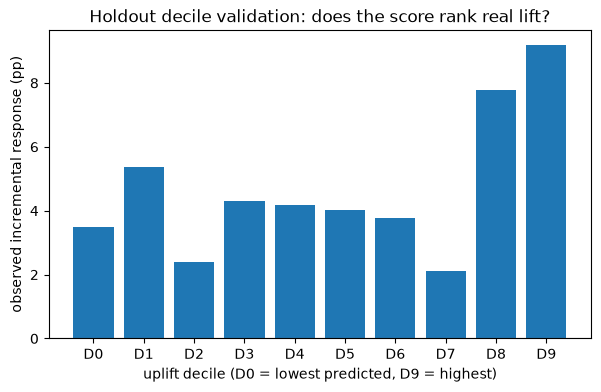

In [82]:
# holdout 排序有效性：按 T-learner 分数切 10 个等人数 decile，逐档看观测增量。
# 目的仅为验证「排序把增量大的人排前面」，不是部署策略、也不主张只投某个 top-k。
val = pd.DataFrame({
    "score": np.asarray(t_scores),
    "y":     np.asarray(y_te),
    "t":     np.asarray(t_te),
})
# 用 rank 打散并列分数，保证 10 档人数均等（D0 = 最低分, D9 = 最高分）
val["decile"] = pd.qcut(val["score"].rank(method="first"),
                        10, labels=[f"D{i}" for i in range(10)])

def _incr(g):
    tr = g.loc[g["t"] == 1, "y"].mean()   # treated 转化率
    ct = g.loc[g["t"] == 0, "y"].mean()   # control 转化率
    return pd.Series({"n": len(g), "treat": tr, "control": ct,
                      "uplift_pp": (tr - ct) * 100})

dec = val.groupby("decile", observed=True)[["y", "t"]].apply(_incr)
print(dec.iloc[::-1].round({"treat": 4, "control": 4, "uplift_pp": 2}).to_string())

# 稳健口径：报「最高 20%（D8-D9）」vs「全体加权平均」，不报脆弱的 top/bottom 单档比
# （中间档有噪声，单挑某一档当 bottom 会失真）
top20   = dec.loc[["D9", "D8"], "uplift_pp"].mean()
overall = (dec["uplift_pp"] * dec["n"]).sum() / dec["n"].sum()
print(f"\n[ranking check] top-20% (D8-D9) mean uplift {top20:+.2f}pp "
      f"vs overall {overall:+.2f}pp  ->  {top20 / overall:.1f}x")
print("note: lift is concentrated in the top ~20%; middle deciles are flat/noisy "
      "(consistent with the small Qini) - an honest weak-HTE result")

# 每档观测增量（pp）柱状图。标签用英文，避免 matplotlib 缺 CJK 字体导致方块（tofu）
fig, ax = plt.subplots(figsize=(7, 4))
order = [f"D{i}" for i in range(10)]
ax.bar(order, dec.loc[order, "uplift_pp"], color="#1f77b4")
ax.axhline(0, color="grey", lw=0.8)
ax.set_xlabel("uplift decile (D0 = lowest predicted, D9 = highest)")
ax.set_ylabel("observed incremental response (pp)")
ax.set_title("Holdout decile validation: does the score rank real lift?")
plt.show()

### Step 8 · 投放策略 + 业务价值 + 护栏

**口径先说清**：上线与否由 Step 5 的**全员 ATE(+3.4pp)** 决定——这里**不是**主张「只投一部分」。本格模拟的是另一个问题：**当预算 / ROI 只够触达一部分人时**，按分数优先触达能拿回多少增量、省多少成本。**k 由预算决定**，下面的 **30% 只是一个演示值**（换成任意预算比例都成立）。

在「预算受限 → 优先触达前 k%」这个假设下量化价值，并加护栏：
- **护栏 1（不能帮倒忙）**：被选中组的 uplift 应明显高于未选中组，否则模型没把「会被打动的人」挑出来；
- **护栏 2（别刷忠诚用户）**：检查是不是只在给本来就会买的 champions 发券（那样增量很低）。

In [83]:
# k_percent = 预算 / ROI 允许触达的比例（此处 0.30 仅为演示；上线与否已由 Step 5 全员 ATE 决定）
k_percent = 0.30
scores = np.asarray(t_scores)
yv, tv = y_te.values, t_te.values
cutoff = np.quantile(scores, 1 - k_percent)
top = scores >= cutoff

def measured_uplift(mask):
    yt = yv[mask & (tv == 1)]
    yc = yv[mask & (tv == 0)]
    if not len(yt) or not len(yc):
        return float("nan")
    return float(yt.mean() - yc.mean())

up_top, up_rest = measured_uplift(top), measured_uplift(~top)
print(f"只发给 uplift 最高的前 {k_percent:.0%}（cutoff={cutoff:.5f}），共 {int(top.sum())} 人")
print(f"被选中组 uplift = {up_top:.5f}  未选中组 uplift = {up_rest:.5f}（分离度 {up_top/up_rest:.1f}x）")

# 业务价值：把每组的实测 uplift 乘以人数得到增量购买，比较「只发 top-k%」vs「全发」
incr_top = up_top * top.sum()
incr_all = up_top * top.sum() + up_rest * (~top).sum()
captured = incr_top / incr_all
print(f"[价值] 只发前 {k_percent:.0%} 就能拿到全发 ~{captured:.0%} 的增量，"
      f"却只花 {k_percent:.0%} 的触达成本（省 ~{1-k_percent:.0%}）")

# 护栏 2：被选中的人里 champions 占比别高于人群基线（否则是在给反正会买的人发券）
segv = seg_te.values
share_champ = float((segv[top] == "champions").mean())
base_champ  = float((segv == "champions").mean())
ok = share_champ <= base_champ
print(f"[护栏] 被选中组 champions 占比 = {share_champ:.2f} vs 人群 {base_champ:.2f} -> "
      f"{'OK（没在薅忠诚会员）' if ok else 'WATCH（可能在给反正会买的人发券）'}")

只发给 uplift 最高的前 30%（cutoff=0.05142），共 5401 人
被选中组 uplift = 0.06363  未选中组 uplift = 0.04194（分离度 1.5x）
[价值] 只发前 30% 就能拿到全发 ~39% 的增量，却只花 30% 的触达成本（省 ~70%）
[护栏] 被选中组 champions 占比 = 0.14 vs 人群 0.25 -> OK（没在薅忠诚会员）


### Step 9 · 上线化：漂移监控 + 反馈闭环

一次性实验会掩盖两个生产现实：
1. **漂移** — 客群和 uplift 分数分布会随时间移动。用 **PSI** 监控分数（经验值：<0.1 稳定，0.1~0.25 中等，>0.25 明显漂移要重训）。
2. **selective labels / 反馈陷阱** — 一旦只给 top-k% 发券，未来日志只剩被选中尾部的结果，模型会在自己塑造的数据上训练，固化偏好。
   解法：每个周期留一小撮**随机对照组**（epsilon 探索），让无偏的 treated/control 结果持续回流。

In [84]:
def psi(expected, actual, bins=10):
    """Population Stability Index：参考分布 vs 新分布的偏移程度。bins 固定在参考分位上。"""
    edges = np.quantile(expected, np.linspace(0, 1, bins + 1))
    edges[0], edges[-1] = -np.inf, np.inf
    e = np.histogram(expected, edges)[0] / len(expected)
    a = np.histogram(actual, edges)[0] / len(actual)
    e, a = np.clip(e, 1e-6, None), np.clip(a, 1e-6, None)   # 避免 log(0)
    return float(np.sum((a - e) * np.log(a / e)))

# 示意：把测试集分数切两半当「参考期 vs 近期」，监控分数漂移（生产里接真实时间段）
scores = np.asarray(t_scores)
half = len(scores) // 2
val = psi(scores[:half], scores[half:])
flag = "OK" if val < 0.1 else ("WATCH" if val < 0.25 else "DRIFT")
print(f"uplift 分数 PSI（参考 vs 近期）= {val:.3f} -> {flag}")
print("反馈闭环：每个周期保留 epsilon 随机对照组，让无偏结果持续回流（修 selective labels）。")

# --- epsilon-greedy 投放示意：explore（随机）+ exploit（模型 top-k%）---
# 把测试集当作「本周期的候选用户池」。生产里换成当期真实用户。
def epsilon_greedy_targeting(scores, epsilon=0.05, k_percent=0.30, seed=0):
    """把一个周期的用户分成 explore（无偏回流）和 exploit（按模型投放）两支。

    - explore：随机抽 epsilon 比例的用户，内部再随机 treat/control（一个小 A/B），
      给高低分段都留下无偏的 treated/control 结果，专治 selective labels；
    - exploit：其余用户里，只给预测 uplift 最高的 top-k% 发券（就是 Step 8 的策略）。
    返回每个用户的动作标签，方便回流建库。
    """
    rng = np.random.default_rng(seed)
    n = len(scores)
    action = np.empty(n, dtype=object)

    # 1) explore 池：随机抽 epsilon%（不看分数）
    explore = rng.random(n) < epsilon
    # explore 内部再随机一半发/一半不发 —— 这就是持续回流的无偏 A/B
    coin = rng.random(n) < 0.5
    action[explore & coin] = "explore_treat"
    action[explore & ~coin] = "explore_control"

    # 2) exploit 池：剩下的人里按 Step 8 只发 uplift top-k%
    exploit = ~explore
    cutoff = np.quantile(scores[exploit], 1 - k_percent)   # 只在 exploit 池里定阈值
    action[exploit & (scores >= cutoff)] = "exploit_treat"
    action[exploit & (scores < cutoff)] = "exploit_skip"
    return action

act = epsilon_greedy_targeting(scores, epsilon=0.05, k_percent=0.30)
uniq, cnt = np.unique(act, return_counts=True)
print("\n[epsilon-greedy 分桶]", dict(zip(uniq.tolist(), cnt.tolist())))
n_explore = np.char.startswith(act.astype(str), "explore").sum()
print(f"explore（随机对照，无偏回流）= {n_explore} 人（≈{n_explore/len(act):.1%}）; "
      f"其余按模型 top-30% 投放。下周期用 explore 里的 treated/control 重新验证 uplift。")

uplift 分数 PSI（参考 vs 近期）= 0.002 -> OK
反馈闭环：每个周期保留 epsilon 随机对照组，让无偏结果持续回流（修 selective labels）。

[epsilon-greedy 分桶] {'exploit_skip': 11963, 'exploit_treat': 5127, 'explore_control': 493, 'explore_treat': 421}
explore（随机对照，无偏回流）= 914 人（≈5.1%）; 其余按模型 top-30% 投放。下周期用 explore 里的 treated/control 重新验证 uplift。


### Step 10 · 结语 / 下一步

到这里，30% 数据上的整条链路已经跑通：加载 → SQL 特征 → 产品分析 → 实验体检 → ATE → uplift → 评估 → 投放 → 监控。

**开发完成后要做的事**（也就是从这份 notebook 走向 `pipeline.py` 的过程）：
1. 把每一步的内联代码收敛成函数（`step1_load` … `step9_monitoring`），写好 docstring；
2. 把 `SAMPLE_FRAC` 提成参数（`pipeline.py` 默认 0.3）；全量（~4580 万行）在 8GB 笔记本上 DuckDB 聚合会 OOM，需更大内存的机器才能 `sample_frac=None`；
3. 写一页决策备忘录 `decision_memo.md`（产品现状 + 增量效果 + 投放建议 + 局限 + 监控计划）；
4. `showcase.ipynb` 则改成 `import pipeline` 直接调函数，作为对外展示版。

> 提速：把最上面的 `SAMPLE_FRAC` 改成 `0.1` 做更快的迭代（结论结构不变，只是 uplift 信号更抖）。想跑全量需要 >8GB 内存的机器。